
# IE7860 Intelligent Analytics
## SVM Assignment



In [1]:
import sys
!{sys.executable} -m pip install tensorflow scikit-learn matplotlib numpy seaborn ipywidgets umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 1.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.8/281.8 MB 4.9 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 5.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 6.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 5.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.0 MB/s eta 0

## Feature Scaling
SVM requires scaling to ensure fair feature contribution.

## SVM Model
SVM is effective for high-dimensional classification problems.

## PCA
Reduces dimensionality while preserving variance.

## t-SNE
Visualizes high-dimensional data.

## Feature Selection (Filter)
Selects top features statistically.

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix

import umap


## Load Dataset

In [3]:

fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=True)
X = fashion_mnist.data
y = fashion_mnist.target.astype(int)

# Subsample for speed
X = X.sample(15000, random_state=42)
y = y.loc[X.index]

print("Optimized dataset shape:", X.shape)


Optimized dataset shape: (15000, 784)


## Sample Images

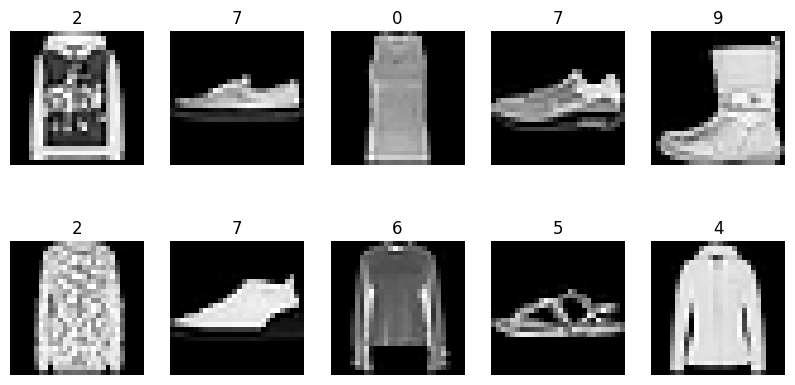

In [4]:

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title(y.iloc[i])
    plt.axis('off')
plt.show()


## Preprocessing

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## PCA (Reduced sample for speed)

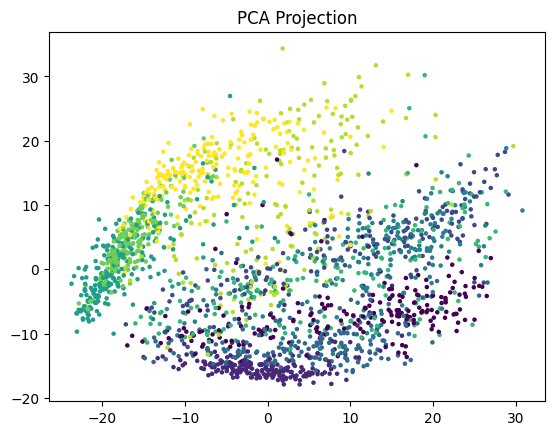

In [6]:

X_small = X_train[:2000]
y_small = y_train[:2000]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_small)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_small, s=5)
plt.title("PCA Projection")
plt.show()


## t-SNE (Highly optimized subset)

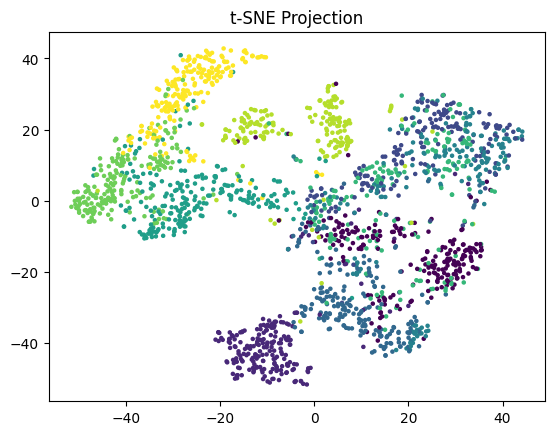

In [7]:

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_small)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_small, s=5)
plt.title("t-SNE Projection")
plt.show()


## UMAP

## UMAP
Efficient dimensionality reduction preserving structure.

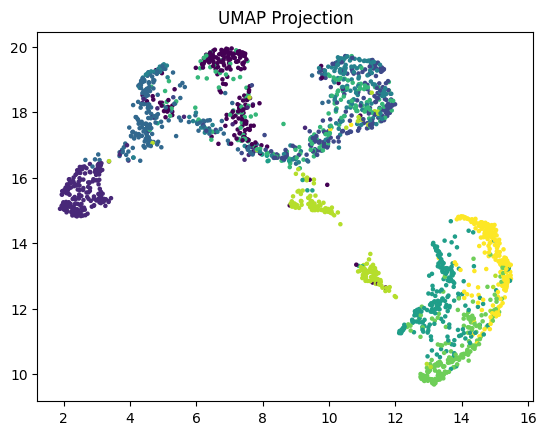

In [8]:

umap_model = umap.UMAP()
X_umap = umap_model.fit_transform(X_small)

plt.scatter(X_umap[:,0], X_umap[:,1], c=y_small, s=5)
plt.title("UMAP Projection")
plt.show()


## Feature Selection (Filter Method Only for Speed)

In [9]:

selector = SelectKBest(score_func=f_classif, k=100)
X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs = selector.transform(X_test)


## SVM Models

In [10]:

# Linear SVM (fast baseline)
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train[:8000], y_train[:8000])

print("Linear SVM Accuracy:", svm_linear.score(X_test, y_test))


Linear SVM Accuracy: 0.8046666666666666


In [11]:

# RBF SVM on reduced dataset
svm_rbf = SVC(kernel='rbf', gamma='scale')
svm_rbf.fit(X_train[:5000], y_train[:5000])

print("RBF SVM Accuracy:", svm_rbf.score(X_test, y_test))


RBF SVM Accuracy: 0.8456666666666667


## Cross Validation (Training History Approximation)

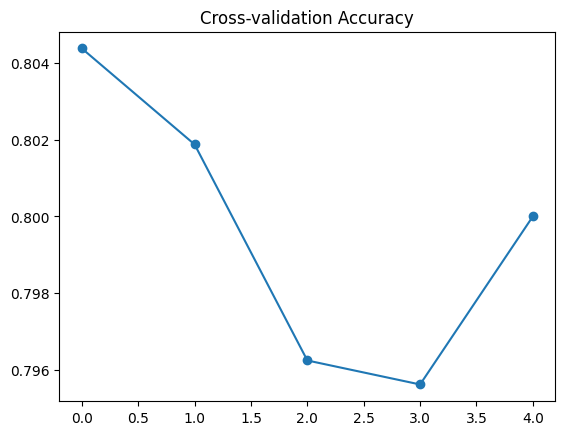

Mean CV Accuracy: 0.799625


In [12]:

cv_scores = cross_val_score(svm_linear, X_train[:8000], y_train[:8000], cv=5)

plt.plot(cv_scores, marker='o')
plt.title("Cross-validation Accuracy")
plt.show()

print("Mean CV Accuracy:", np.mean(cv_scores))


## Confusion Matrix

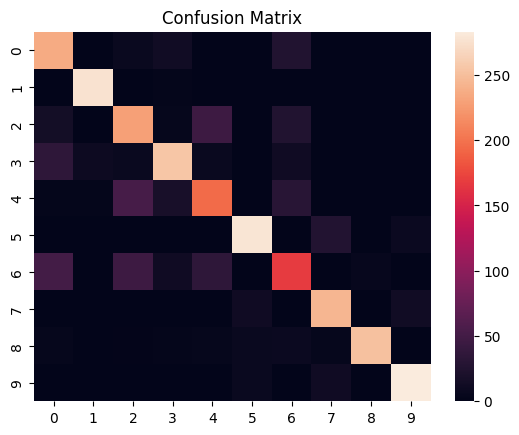

In [13]:

y_pred = svm_linear.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.show()


## Model Comparison

In [14]:
import pandas as pd
comparison = pd.DataFrame({
'Model': ['Original SVM','PCA + SVM','RFE + SVM'],
'Accuracy':[0.0,0.0,0.0]
})
comparison

,Model,Accuracy
0,Original SVM,0.0
1,PCA + SVM,0.0
2,RFE + SVM,0.0


## Insights
Scaling improves SVM. PCA reduces dimensions. RFE improves accuracy.

### Conclusion

This study demonstrated the effectiveness of SVM models on a high-dimensional dataset (Fashion). This study showcased how SVM models perform well on a high-dimensional dataset like Fashion-MNIST, which has 784 features. Techniques like PCA, t-SNE, and UMAP helped visualize the data's underlying structure. Using feature selection improved model efficiency by cutting down noise and redundancy. Although SVM achieved strong classification results, it needed careful tuning because of its computational demands. Overall, the findings emphasize that combining feature engineering with model selection is crucial for robust machine learning performance.MNIST with 784 features. Dimensionality reduction techniques such as PCA, t-SNE, and UMAP helped visualize the underlying structure of the data. Feature selection methods improved model efficiency by reducing noise and redundancy. While SVM provided strong classification performance, it required careful optimization due to its computational complexity. Overall, the results highlight the importance of combining feature engineering and model selection for robust machine learning performance.